In [ ]:
from datetime import datetime
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('/Users/xinc/GitHub/Quant')
NOTE_DIR = REPO_ROOT.parent / 'note'
PROJECT_DIR = REPO_ROOT / 'projects/workStrategy/TX'
sys.path.extend([str(NOTE_DIR), str(REPO_ROOT), str(PROJECT_DIR)])

from module.get_info_FinMind import FinMindClient
from analyzer import TXAnalyzer

START = '2020-01-01'
END = datetime.now().strftime('%Y-%m-%d')
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.05
ONE_WAY_COST = 0.00002  # 2 bps per 1x notional turnover; adjust to actual fee + slippage

In [2]:
# Load paired day/night TX data.  Reuse the same source and session alignment as factor_research.ipynb.
fm = FinMindClient()
fm.initialize_frame(stock_id='TX', start_time=START, end_time=END)
analyzer = TXAnalyzer(fm.get_future_price())
alignment = analyzer.session_alignment_report()
display(alignment)

split_dates = TXAnalyzer.split_periods(
    analyzer.display_df().index,
    start='2020-01-01',
    train_ratio=TRAIN_RATIO,
    validation_ratio=VALIDATION_RATIO,
)
pd.Series(split_dates, name='date')


[LOCAL] finmind/future_price -> /Users/xinc/GitHub/google_drive/Data/trading/tw_futures/TX.csv


total_dates                1595
paired_day_night_dates     1588
day_only_dates                0
night_only_dates              7
missing_both_dates            0
duplicate_dates               0
close_date_alignment_ok    True
Name: session_alignment, dtype: object

train_end          2024-08-01
validation_start   2024-08-02
validation_end     2024-11-22
test_start         2024-11-25
Name: date, dtype: datetime64[ns]

In [3]:
# Indicator methods return already-lagged series, so today's close is never used for today's trade.
features = pd.concat({
    'day_divergence': analyzer.indicator_ma_divergence(25, return_series=True),
    'night_divergence': analyzer.indicator_ma_divergence(5, return_series=True),
    'hist_vol_40': analyzer.indicator_hist_vol(40, return_series=True),
}, axis=1).reindex(analyzer.display_df().index)
night_vol_q5 = features.loc[:split_dates['train_end'], 'hist_vol_40'].quantile(0.80)

positions = pd.DataFrame(index=features.index)
positions['pos_day'] = np.where(
    features['day_divergence'].le(-0.021)
    & features['hist_vol_40'].between(0.0075, 0.00963, inclusive='both'), -1.0, 0.0
)
positions['pos_night'] = np.where(
    features['night_divergence'].le(-0.018) & features['hist_vol_40'].ge(night_vol_q5), 1.0, 0.0
)
pd.Series({'night vol Q5 (training only)': night_vol_q5, 'day trades': (positions.pos_day != 0).sum(), 'night trades': (positions.pos_night != 0).sum()})


night vol Q5 (training only)     0.008921
day trades                      50.000000
night trades                    32.000000
dtype: float64

In [4]:
result = analyzer.evaluate(positions, one_way_cost=ONE_WAY_COST)
result = result.join(features[['day_divergence', 'night_divergence', 'hist_vol_40']])
result[['day_divergence', 'night_divergence', 'hist_vol_40', 'pos_day', 'pos_night', 'strat_ret']].tail()


,day_divergence,night_divergence,hist_vol_40,pos_day,pos_night,strat_ret
2026-07-14,NaN,NaN,NaN,0.0,0.0,0.0
2026-07-15,NaN,NaN,NaN,0.0,0.0,0.0
2026-07-16,NaN,NaN,NaN,0.0,0.0,0.0
2026-07-17,NaN,NaN,NaN,0.0,0.0,0.0
2026-07-20,NaN,-0.049233,NaN,0.0,0.0,0.0


In [5]:
periods = {
    'train': (result.index.min(), split_dates['train_end']),
    'validation': (split_dates['validation_start'], split_dates['validation_end']),
    'test': (split_dates['test_start'], result.index.max()),
}
summary = {}
for name, (start, end) in periods.items():
    sample = result.loc[start:end]
    summary[name] = analyzer.summarize_result(sample)
summary = pd.DataFrame(summary)
summary.T

,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Max DD Duration,Profit Factor,Win Rate,Odds,Avg Win,Avg Loss,Avg Return (Exp),Kelly,Annual Turnover
train,0.132052,0.028481,0.054673,0.541039,-0.078295,502.0,1.551733,0.485714,1.643011,0.010807,-0.006578,0.001866,0.17270,9.032258
validation,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
test,0.188202,0.115062,0.120269,0.964318,-0.088100,143.0,2.172026,0.400000,3.258039,0.021269,-0.006528,0.004591,0.21584,21.420000


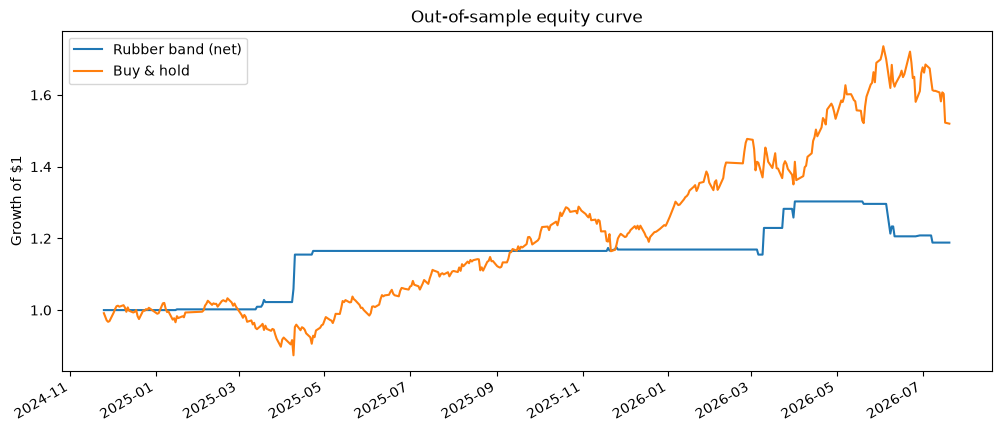

,day_divergence,night_divergence,hist_vol_40,pos_day,pos_night,gross_ret,cost,strat_ret
2025-01-16,-0.023990,-0.011961,0.007536,-1.0,0.0,0.002123,0.00002,0.002103
2025-03-14,-0.049962,-0.013936,0.007709,-1.0,0.0,0.007188,0.00002,0.007168
2025-03-17,-0.045987,-0.007098,0.007666,-1.0,0.0,0.000135,0.00000,0.000135
2025-03-18,-0.035295,0.004424,0.007643,-1.0,0.0,0.006392,0.00000,0.006392
2025-03-19,-0.030445,0.005873,0.007639,-1.0,0.0,0.012321,0.00000,0.012321
2025-03-20,-0.039750,-0.003747,0.007867,-1.0,0.0,-0.005801,0.00000,-0.005801
2025-04-09,-0.166981,-0.096023,0.008141,-1.0,0.0,0.035974,0.00002,0.035954
2025-04-10,-0.204096,-0.113616,0.009765,0.0,1.0,0.090332,0.00004,0.090292
2025-04-23,-0.083790,-0.022446,0.013363,0.0,1.0,0.008895,0.00002,0.008875
2025-11-19,-0.035665,-0.026823,0.007730,-1.0,0.0,0.007162,0.00002,0.007142


Test day-session trades: 13
Test night-session trades: 13


In [6]:
# Inspect the strictly out-of-sample period before deciding whether to deploy.
test = result.loc[split_dates['test_start']:].copy()
equity = pd.DataFrame({
    'Rubber band (net)': (1 + test['strat_ret'].fillna(0)).cumprod(),
    'Buy & hold': (1 + test['benchmark_ret'].fillna(0)).cumprod(),
})
ax = equity.plot(figsize=(12, 5), title='Out-of-sample equity curve')
ax.set_ylabel('Growth of $1')
plt.show()

signal_log = test.loc[(test['pos_day'] != 0) | (test['pos_night'] != 0), [
    'day_divergence', 'night_divergence', 'hist_vol_40',
    'pos_day', 'pos_night', 'gross_ret', 'cost', 'strat_ret',
]]
display(signal_log.tail(30))
print('Test day-session trades:', int((test['pos_day'] != 0).sum()))
print('Test night-session trades:', int((test['pos_night'] != 0).sum()))
